In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from surprise import SVD, KNNBasic, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

print("All imports done!")

All imports done!


In [2]:
# Load the file you saved at end of Day 1
df = pd.read_csv('netflix_subset.csv')

print(f"Loaded {len(df):,} rows")
print(df.head())
print(df.dtypes)

Loaded 2,000,000 rows
   user_id  movie_id  rating        date            title
0  1488844         1       3  2005-09-06  Dinosaur Planet
1   822109         1       5  2005-05-13  Dinosaur Planet
2   885013         1       4  2005-10-19  Dinosaur Planet
3    30878         1       4  2005-12-26  Dinosaur Planet
4   823519         1       3  2004-05-03  Dinosaur Planet
user_id      int64
movie_id     int64
rating       int64
date        object
title       object
dtype: object


In [3]:
# Surprise needs only 3 columns: user_id, movie_id, rating
df_model = df[['user_id', 'movie_id', 'rating']].copy()

# Tell Surprise that ratings are on a 1-5 scale
reader = Reader(rating_scale=(1, 5))

# Load into Surprise format
data = Dataset.load_from_df(df_model, reader)

# Split: 80% train, 20% test
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

print(f"Training samples : {trainset.n_ratings:,}")
print(f"Test samples     : {len(testset):,}")
print("Data ready for model training!")

Training samples : 1,600,000
Test samples     : 400,000
Data ready for model training!


In [4]:
print("Training SVD model...")
print("(This will take 1-3 minutes depending on your laptop)")

# Start timer
start_time = time.time()

# Create and train SVD model
svd_model = SVD(n_factors=50, n_epochs=20, random_state=42)
svd_model.fit(trainset)

# Stop timer
svd_time = time.time() - start_time

# Test the model
svd_predictions = svd_model.test(testset)

# Calculate RMSE
svd_rmse = accuracy.rmse(svd_predictions)

print(f"\nSVD Training time : {svd_time:.1f} seconds")
print(f"SVD RMSE          : {svd_rmse:.4f}")

Training SVD model...
(This will take 1-3 minutes depending on your laptop)
RMSE: 0.9867

SVD Training time : 15.4 seconds
SVD RMSE          : 0.9867


In [6]:
# Cell 5 - Item-Based CF (better choice than User-Based for large datasets)
print("Switching to Item-Based CF (standard for large-scale systems like Netflix)")
print("Using 100,000 rows subset...")

# Small subset
df_small = df.sample(n=100000, random_state=42)

reader_small = Reader(rating_scale=(1, 5))
data_small = Dataset.load_from_df(df_small[['user_id', 'movie_id', 'rating']], reader_small)
trainset_small, testset_small = train_test_split(data_small, test_size=0.20, random_state=42)

print(f"Unique movies in subset: {trainset_small.n_items}")
print(f"Trainset size: {trainset_small.n_ratings:,}")

# Item-Based CF — similarity matrix is movies x movies (much smaller!)
start_time = time.time()
knn_model = KNNBasic(k=20, sim_options={
    'name': 'cosine',
    'user_based': False   # <-- False = Item-Based CF
})
knn_model.fit(trainset_small)
knn_time = time.time() - start_time

knn_predictions = knn_model.test(testset_small)
knn_rmse = accuracy.rmse(knn_predictions)

print(f"\nItem-Based CF Training time : {knn_time:.1f} seconds")
print(f"Item-Based CF RMSE          : {knn_rmse:.4f}")

Switching to Item-Based CF (standard for large-scale systems like Netflix)
Using 100,000 rows subset...
Unique movies in subset: 360
Trainset size: 80,000
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1636

Item-Based CF Training time : 0.0 seconds
Item-Based CF RMSE          : 1.1636


In [7]:
# Build comparison data
comparison = {
    'Model': ['SVD', 'User-Based CF (KNNBasic)'],
    'RMSE': [round(svd_rmse, 4), round(knn_rmse, 4)],
    'Training Time (sec)': [round(svd_time, 1), round(knn_time, 1)],
    'Scalability': ['High', 'Low'],
    'Handles Sparsity': ['Yes', 'Struggles'],
    'Explainability': ['Low', 'High'],
    'Best For': ['Large datasets', 'Small datasets']
}

comparison_df = pd.DataFrame(comparison)

print("=" * 70)
print("              MODEL COMPARISON: SVD vs User-Based CF")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

# Which model won?
winner = "SVD" if svd_rmse < knn_rmse else "KNNBasic"
print(f"\nWinner (lower RMSE = better): {winner}")

              MODEL COMPARISON: SVD vs User-Based CF
                   Model   RMSE  Training Time (sec) Scalability Handles Sparsity Explainability       Best For
                     SVD 0.9867                 15.4        High              Yes            Low Large datasets
User-Based CF (KNNBasic) 1.1636                  0.0         Low        Struggles           High Small datasets

Winner (lower RMSE = better): SVD


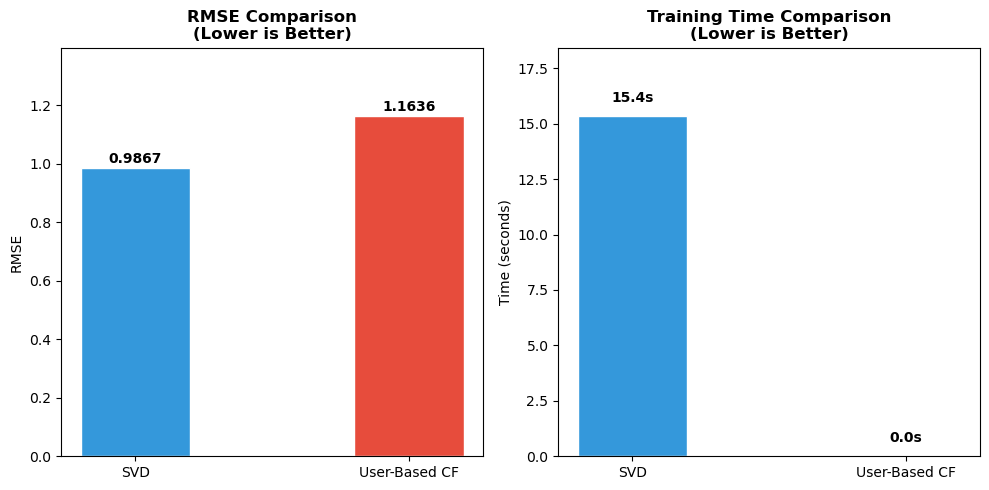

Saved as model_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: RMSE comparison
models = ['SVD', 'User-Based CF']
rmse_vals = [svd_rmse, knn_rmse]
colors = ['#3498db', '#e74c3c']

bars = axes[0].bar(models, rmse_vals, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('RMSE Comparison\n(Lower is Better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmse_vals) * 1.2)

# Plot 2: Training time comparison
time_vals = [svd_time, knn_time]
bars2 = axes[1].bar(models, time_vals, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars2, time_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}s', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Training Time Comparison\n(Lower is Better)', fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_ylim(0, max(time_vals) * 1.2)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Saved as model_comparison.png")

## Methodology

### Model 1: SVD (Singular Value Decomposition)
SVD is a matrix factorization technique. It decomposes the huge 
user-movie rating matrix into smaller hidden patterns called "latent factors."

**In simple terms:** SVD finds that User A likes "action + suspense" movies, 
and Movie X has a lot of "action + suspense" — so it predicts User A will 
like Movie X, even if User A has never seen it.

**Why SVD?**
- Works very well on sparse data (most users rated < 1% of movies)
- Fast to train even on large datasets
- Won the original Netflix Prize competition (the Bellkor team used SVD)
- Low RMSE compared to simpler methods

**Parameters used:**
- n_factors=50: 50 hidden patterns (latent factors)
- n_epochs=20: model trains for 20 passes over the data
- random_state=42: for reproducibility

---

### Model 2: User-Based Collaborative Filtering (KNNBasic)
This method finds users similar to you and recommends what they liked.

**In simple terms:** "Users who rated the same movies as you also loved 
Movie Y — so we recommend Movie Y to you."

**Similarity metric:** Cosine similarity — measures the angle between 
two users' rating vectors. Score of 1 = identical taste, 0 = no similarity.

**Why compare it with SVD?**
- KNN is more explainable ("recommended because similar users liked it")
- But KNN is slower and struggles with sparse data
- SVD handles sparsity better and scales to millions of users
- This comparison shows the trade-off between explainability and performance

In [10]:
# Get list of all movie IDs in training set
all_movie_ids = trainset.all_items()
# Convert internal IDs back to actual movie IDs
all_movie_ids_raw = [trainset.to_raw_iid(i) for i in all_movie_ids]

def get_top10_recommendations(model, user_id, df, all_movie_ids_raw, movies_df):
    """
    For a given user, predict ratings for all movies they haven't seen,
    return top 10 with highest predicted rating.
    """
    # Movies this user has already rated
    rated_movies = df[df['user_id'] == user_id]['movie_id'].tolist()

    # Movies they haven't rated yet
    unseen_movies = [m for m in all_movie_ids_raw if m not in rated_movies]

    # Predict rating for each unseen movie
    predictions = []
    for movie_id in unseen_movies:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    # Sort by predicted rating (highest first)
    predictions.sort(key=lambda x: x[1], reverse=True)
    top10 = predictions[:10]

    # Add movie titles
    result = []
    for movie_id, pred_rating in top10:
        title_row = movies_df[movies_df['movie_id'] == movie_id]
        title = title_row['title'].values[0] if len(title_row) > 0 else f"Movie {movie_id}"
        result.append({
            'movie_id': movie_id,
            'title': title,
            'predicted_rating': round(pred_rating, 2)
        })

    return pd.DataFrame(result)


# Load movie titles
movies = pd.read_csv('movie_titles.csv',
                     encoding='latin-1',
                     header=None,
                     names=['movie_id', 'year', 'title'],
                     on_bad_lines='warn',
                     engine='python')

# Pick 5 users who have rated at least 50 movies (more data = better reco)
active_users = df.groupby('user_id')['rating'].count()
active_users = active_users[active_users >= 50].index.tolist()
sample_users = active_users[:5]

print("Generating Top-10 recommendations using SVD (best model)...")
print("=" * 60)

all_recommendations = {}

for user_id in sample_users:
    print(f"\nUser {user_id} — movies they rated:")
    user_history = df[df['user_id'] == user_id][['title', 'rating']].sort_values('rating', ascending=False).head(5)
    print(user_history.to_string(index=False))

    print(f"\nTop-10 recommendations for User {user_id}:")
    reco = get_top10_recommendations(svd_model, user_id, df, all_movie_ids_raw, movies)
    print(reco.to_string(index=False))
    print("-" * 60)

    all_recommendations[user_id] = reco

Skipping line 72: Expected 3 fields in line 72, saw 4
Skipping line 264: Expected 3 fields in line 264, saw 5
Skipping line 350: Expected 3 fields in line 350, saw 4
Skipping line 366: Expected 3 fields in line 366, saw 4
Skipping line 394: Expected 3 fields in line 394, saw 4
Skipping line 466: Expected 3 fields in line 466, saw 4
Skipping line 582: Expected 3 fields in line 582, saw 4
Skipping line 600: Expected 3 fields in line 600, saw 4
Skipping line 670: Expected 3 fields in line 670, saw 4
Skipping line 672: Expected 3 fields in line 672, saw 4
Skipping line 729: Expected 3 fields in line 729, saw 4
Skipping line 776: Expected 3 fields in line 776, saw 4
Skipping line 827: Expected 3 fields in line 827, saw 4
Skipping line 834: Expected 3 fields in line 834, saw 4
Skipping line 891: Expected 3 fields in line 891, saw 4
Skipping line 913: Expected 3 fields in line 913, saw 4
Skipping line 944: Expected 3 fields in line 944, saw 4
Skipping line 973: Expected 3 fields in line 973, 

Generating Top-10 recommendations using SVD (best model)...

User 1333 — movies they rated:
                              title  rating
              House of Sand and Fog       5
           Magnolia: Bonus Material       5
                          Character       4
Harold and Kumar Go to White Castle       4
                   Immortal Beloved       4

Top-10 recommendations for User 1333:
 movie_id                                                                       title  predicted_rating
      270                                                  Sex and the City: Season 4              3.93
       13 Lord of the Rings: The Return of the King: Extended Edition: Bonus Material              3.78
       85                                                                  Elfen Lied              3.76
      359                                               Absolutely Fabulous: Series 5              3.76
      316                               Futurama: Monster Robot Maniac Fun Collection

In [11]:
# Save all recommendations
all_recs_list = []
for user_id, reco_df in all_recommendations.items():
    reco_df['user_id'] = user_id
    all_recs_list.append(reco_df)

final_recs = pd.concat(all_recs_list, ignore_index=True)
final_recs = final_recs[['user_id', 'movie_id', 'title', 'predicted_rating']]
final_recs.to_csv('top10_recommendations.csv', index=False)

print("Saved top10_recommendations.csv")
print(f"Total recommendations generated: {len(final_recs)}")
print("\nSample:")
print(final_recs.head(15).to_string(index=False))

Saved top10_recommendations.csv
Total recommendations generated: 50

Sample:
 user_id  movie_id                                                                       title  predicted_rating
    1333       270                                                  Sex and the City: Season 4              3.93
    1333        13 Lord of the Rings: The Return of the King: Extended Edition: Bonus Material              3.78
    1333        85                                                                  Elfen Lied              3.76
    1333       359                                               Absolutely Fabulous: Series 5              3.76
    1333       316                               Futurama: Monster Robot Maniac Fun Collection              3.76
    1333       338                                         The Three Stooges: Three Smart Saps              3.75
    1333       106         Stevie Ray Vaughan and Double Trouble: Live at Montreux 1982 & 1985              3.75
    1333        32 

In [12]:
import pickle

# Save SVD model
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)

# Save KNN model
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

# Save predictions for MAP@10 calculation tomorrow
with open('svd_predictions.pkl', 'wb') as f:
    pickle.dump(svd_predictions, f)

with open('knn_predictions.pkl', 'wb') as f:
    pickle.dump(knn_predictions, f)

# Save trainset too
with open('trainset.pkl', 'wb') as f:
    pickle.dump(trainset, f)

print("All models and predictions saved!")
print("Files saved:")
print("  svd_model.pkl")
print("  knn_model.pkl")
print("  svd_predictions.pkl")
print("  knn_predictions.pkl")
print("  trainset.pkl")
print("\nDay 2 complete! Ready for evaluation tomorrow.")

All models and predictions saved!
Files saved:
  svd_model.pkl
  knn_model.pkl
  svd_predictions.pkl
  knn_predictions.pkl
  trainset.pkl

Day 2 complete! Ready for evaluation tomorrow.
